# Laboration 3: Optimising a Catalytic Reaction

**Team name:**
**Members:**
**Date:**

Follow `instruction.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Before you start: open `plant_client.py` and fill in `SERVER_URL`,
`TEAM`, and `TOKEN` (given to you by your instructor).

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pyDOE3
from scipy.stats import qmc, t as t_dist
from scipy import stats
from scipy.optimize import minimize

from plant_client import run_experiment, leaderboard

RANDOM_STATE = 42

# Keep every experiment you run here -- you'll need the full history in
# Step 3, not just your latest batch.
history = pd.DataFrame(columns=["T", "c", "rpm", "rate"])

def log(result):
    """Append a run_experiment() result to the running history table."""
    global history
    history = pd.concat([history, result], ignore_index=True)
    return history


# Setup for Colab: download plant_client.py and fill in the server address,
# team name and token, so `from plant_client import ...` below works.
import importlib, re, sys, urllib.request

---
## Step 1 — Factorial Screening (0:00–0:45)

Three candidate factors this time: **c**, **T**, and **stirring rate
(rpm)** — nobody has confirmed rpm actually matters, that's what this
step is for.

- [ ] Design a 2³ factorial (8 corner points) around the OVAT point (c=2.0, T=25.0) and a sensible centre rpm, plus a few centre-point replicates
- [ ] Run it via `run_experiment`
- [ ] Code each factor to +/-1 (e.g. `c_coded = (c - 2.0) / 0.5`) before fitting -- see the TODO below for why this matters
- [ ] Fit `rate ~ c_coded * T_coded * rpm_coded` on the corner points — which effects are significant? (→ **Checkpoint 1a**)
- [ ] If rpm (and its interactions) aren't significant, drop it and fix it at a convenient value from here on
- [ ] Compare centre-point average to corner-point average — is there curvature? (→ **Checkpoint 1b**)

In [22]:
import numpy as np

# TODO:
# 1. choose your factor ranges (e.g. c +/- 0.5 mM, T +/- 5 degC around
# the OVAT point, rpm +/- 200 around a centre value like 500)
# 2. build the 8 corner points (save in a df)
# 3. Build a few centre-point repeats (save in a separate df)

# HINT: itertools.product(levels_c, levels_T, levels_rpm)
# is the easiest way to build the 2^3 corners.
n_reps = 2   # two replicates per design point
design_3 = pyDOE3.ff2n(3)
df_design = pd.DataFrame(design_3, columns=['T', 'c', 'rpm'])
df_coded = df_design
print(df_coded)
# Add natural units
df_design['T'] = 25 + 5*df_design['T']
df_design['c'] = 2   +   0.5*df_design['c']
df_design['rpm'] = 500 + 200*df_design['rpm']

dfcenter = pd.DataFrame([(0,0,0)] * 3, columns=['T', 'c', 'rpm'])
center_val = pd.DataFrame([(25.0, 2.0, 500.0)]*3 , columns=['T', 'c', 'rpm'])
print(dfcenter)
print(center_val)



     T    c  rpm
0 -1.0 -1.0 -1.0
1 -1.0 -1.0  1.0
2 -1.0  1.0 -1.0
3 -1.0  1.0  1.0
4  1.0 -1.0 -1.0
5  1.0 -1.0  1.0
6  1.0  1.0 -1.0
7  1.0  1.0  1.0
   T  c  rpm
0  0  0    0
1  0  0    0
2  0  0    0
      T    c    rpm
0  25.0  2.0  500.0
1  25.0  2.0  500.0
2  25.0  2.0  500.0


In [23]:
# TODO:
# 1. run the design with result = run_experiment(name="...", T=..., c=..., rpm=...).
# You will have to run the corner points and centre-points
# separately (it is needed for the next parts of the lab)
# 2. Use log(result) to add it to `history`.

# TIP: the run_experiment function is defined in plant_client.py.

corner_list = []
center_list = []

print("Running and logging corner point experiments...")
for i, row in df_design.iterrows():
    # Wrap the scalar values in lists as run_experiment expects iterable inputs
    result = run_experiment(name=f"corner_point_{i+1}", T=[row['T']], c=[row['c']], rpm=[row['rpm']])
    log(result)
    corner_list.append(result)

for i, row in center_val.iterrows():
    # Wrap the scalar values in lists as run_experiment expects iterable inputs
    result = run_experiment(name=f"center_point_{i+1}", T=[row['T']], c=[row['c']], rpm=[row['rpm']])
    log(result)
    center_list.append(result)



Running and logging corner point experiments...
'corner_point_1': loaded 1 cached run(s), no new experiments.
'corner_point_2': loaded 1 cached run(s), no new experiments.
'corner_point_3': loaded 1 cached run(s), no new experiments.
'corner_point_4': loaded 1 cached run(s), no new experiments.
'corner_point_5': loaded 1 cached run(s), no new experiments.
'corner_point_6': loaded 1 cached run(s), no new experiments.
'corner_point_7': loaded 1 cached run(s), no new experiments.
'corner_point_8': loaded 1 cached run(s), no new experiments.
'center_point_1': loaded 1 cached run(s), no new experiments.
'center_point_2': loaded 1 cached run(s), no new experiments.
'center_point_3': loaded 1 cached run(s), no new experiments.


/tmp/ipykernel_9699/2518013072.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history = pd.concat([history, result], ignore_index=True)


In [24]:

# TODO:
# 1. For the result, code each factor to +/-1 using the factorial's own half-ranges
# (e.g. c_coded = (c - 2.0) / 0.5) and add these as new columns.
# 2. THEN fit rate ~ c_coded * T_coded * rpm_coded (statsmodels.formula.api.ols)
# ONLY on the corner points. (Fitting on raw units (mM, degC, rpm) instead will give
# you a badly ill-conditioned model where every effect looks non-significant
# that's a red flag to code your variables, not a real finding.)

# TIP: .summary() shows you the coefficients, signs, and p-values for every
# main effect and interaction.
# Define center points and half-ranges for coding

df_model_data = pd.concat(corner_list + center_list, ignore_index=True)
# Code each factor to +/-1
df_model_data['c_coded'] = (df_model_data['c'] - 2) /0.5
df_model_data['T_coded'] = (df_model_data['T'] - 25) /5
df_model_data['rpm_coded'] = (df_model_data['rpm'] - 500) /200

display(df_model_data[['c_coded', 'T_coded', 'rpm_coded', 'rate']])

model = smf.ols(
    'rate ~ c_coded * T_coded * rpm_coded',
    data=df_model_data
).fit()

print("\nOLS Model Summary:")
print(model.summary())


,c_coded,T_coded,rpm_coded,rate
0,-1.0,-1.0,-1.0,3.2950
1,-1.0,-1.0,1.0,3.3052
2,1.0,-1.0,-1.0,5.0280
3,1.0,-1.0,1.0,5.0740
4,-1.0,1.0,-1.0,6.0717
5,-1.0,1.0,1.0,5.9831
6,1.0,1.0,-1.0,7.6099
7,1.0,1.0,1.0,7.5287
8,0.0,0.0,0.0,5.5246
9,0.0,0.0,0.0,5.7880



OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     61.69
Date:                Sat, 10 Oct 2026   Prob (F-statistic):            0.00308
Time:                        08:36:46   Log-Likelihood:                 8.6570
No. Observations:                  11   AIC:                            -1.314
Df Residuals:                       3   BIC:                             1.869
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

Baserat på analysen av OLS-rapporten, om `rpm` och dess interaktioner bedöms vara statistiskt obetydliga (dvs. p-värdena är höga), kan vi förenkla modellen genom att ta bort `rpm` som en variabel.

När du har tagit bort `rpm` som en rörlig variabel från din modell kommer du att använda ett **fast `rpm`-värde** för alla framtida experiment. Detta värde väljs oftast som mittpunkten (t.ex. 500 rpm) från ditt ursprungliga designområde.

In [25]:
# TODO: decide whether to drop rpm based on the model above. If you do,
# note it here (and on the answer sheet, Checkpoint 1a) and pick a fixed      we drop the rpm based
# rpm value to use for the rest of the lab.

fixed_rpm_value = 500.0
print(corner_list)


[      T    c    rpm   rate
0  20.0  1.5  300.0  3.295,       T    c    rpm    rate
0  20.0  1.5  700.0  3.3052,       T    c    rpm   rate
0  20.0  2.5  300.0  5.028,       T    c    rpm   rate
0  20.0  2.5  700.0  5.074,       T    c    rpm    rate
0  30.0  1.5  300.0  6.0717,       T    c    rpm    rate
0  30.0  1.5  700.0  5.9831,       T    c    rpm    rate
0  30.0  2.5  300.0  7.6099,       T    c    rpm    rate
0  30.0  2.5  700.0  7.5287]


In [26]:
# TODO: compare the centre-point average rate to the average of the 8
# corner points. A meaningfully different value suggests curvature.
# Reason about this on the answer sheet (Checkpoint 1b), not just here.

df_corners = pd.concat(corner_list, ignore_index=True)
df_centers = pd.concat(center_list, ignore_index=True)

average_corner_rate = df_corners['rate'].mean()
average_center_rate = df_centers['rate'].mean()

print(f"\nAverage rate for corner points (with fixed rpm): {average_corner_rate:.4f} mol/s")
print(f"Average rate for center points (with fixed rpm): {average_center_rate:.4f} mol/s")

difference = abs(average_center_rate - average_corner_rate)
print(f"Absolut skillnad: {difference:.4f} mol/s")


Average rate for corner points (with fixed rpm): 5.4870 mol/s
Average rate for center points (with fixed rpm): 5.6915 mol/s
Absolut skillnad: 0.2046 mol/s


---
## Step 2 — Steepest Ascent (0:45–1:30)

- [ ] Use the significant main effects from Step 1 (c and T, assuming rpm was dropped) to compute an ascent direction
- [ ] Run a sequence of points stepping along that direction, until the rate stops improving. If you fixed the repm value, keep it fixed at your chosen value.
- [ ] Keep `log()`-ing every result so `history` stays complete

In [27]:
# TODO:
# 1. Compute the steepest-ascent direction from your Step 1 model's c
# and T coefficients (the ratio of the fitted effects gives the relative
# step sizes)
# 2. Choose a step size and take your first step. If you fixed
# your rpm value, pass it on every call.

b1, b2 = model.params['T_coded'], model.params['c_coded']
print(f'First-order coefficients: b1 = {b1:.3f}, b2 = {b2:.3f}')
print(f'Steepest ascent direction: ({b1:.3f}, {b2:.3f})')
#step size
step_T_coded = 0.2

#step size in coded
step_c_coded = step_T_coded * (b2 / b1)

# steps in natural units
step_T = step_T_coded * 5
step_c = step_c_coded * 0.5

print(f"Stegstorlek i fysikaliska enheter:")
print(f"  Delta T: +{step_T:.2f} °C per steg")
print(f"  Delta c: +{step_c:.3f} mM per steg\n")

target_T = 25 + step_T
target_c = 2 + step_c

result = run_experiment(
        name=f"steepest_ascent_stepping_",
        T=[target_T],
        c=[target_c],
        rpm=[fixed_rpm_value]
    )
log(result)
display(history)





First-order coefficients: b1 = 1.311, b2 = 0.823
Steepest ascent direction: (1.311, 0.823)
Stegstorlek i fysikaliska enheter:
  Delta T: +1.00 °C per steg
  Delta c: +0.063 mM per steg

'steepest_ascent_stepping_': loaded 1 cached run(s), no new experiments.


,T,c,rpm,rate
0,20.0,1.500000,300.0,3.2950
1,20.0,1.500000,700.0,3.3052
2,20.0,2.500000,300.0,5.0280
3,20.0,2.500000,700.0,5.0740
4,30.0,1.500000,300.0,6.0717
5,30.0,1.500000,700.0,5.9831
6,30.0,2.500000,300.0,7.6099
7,30.0,2.500000,700.0,7.5287
8,25.0,2.000000,500.0,5.5246
9,25.0,2.000000,500.0,5.7880


In [28]:
# TODO:
# Perform a steepest ascent along the ascent direction, starting from the OVAT point.
# Run the experiments using result = run_experiment(name, T, c, rpm)
# and log each result using log(result).
# Print the best (T, c, rate) you've found so far after each step.
# Continue the steepest ascent until the rate stops improving, using a reasonable criteria.

T_start = 25.0
c_start = 2.0

step_vector_coded = (0.5 / abs(b1)) * np.array([b1, b2])

last_rate = 5.7076
best_rate = last_rate
best_T = T_start
best_c = c_start

max_steps = 15
n_steps = 0

for s in range(1, max_steps + 1):
    n_steps += 1
    current_coded = s * step_vector_coded
    target_T = T_start + current_coded[0] * 5.0
    target_c = c_start + current_coded[1] * 0.5
    experiment_name = f"steepest_ascent_stepnr_{s}"

    result = run_experiment(
        name=experiment_name,
        T=[target_T],
        c=[target_c],
        rpm=[fixed_rpm_value]
    )
    log(result)

    current_rate = result['rate'].iloc[0]
    print(f"Steg {s}: T={target_T:.2f} °C, c={target_c:.3f} mM -> Rate={current_rate:.4f} mol/s")

    if current_rate > best_rate:
        best_rate = current_rate
        best_T = target_T
        best_c = target_c
    else:
        break

print(f"\nSteepest Ascent slutförd efter {n_steps} steg")
print(f"Bästa funna inställningar: T = {best_T:.2f} °C, c = {best_c:.3f} mM (Bästa rate = {best_rate:.4f} mol/s)")
display(history.tail(15))

'steepest_ascent_stepnr_1': loaded 1 cached run(s), no new experiments.
Steg 1: T=27.50 °C, c=2.157 mM -> Rate=6.7040 mol/s
'steepest_ascent_stepnr_2': loaded 1 cached run(s), no new experiments.
Steg 2: T=30.00 °C, c=2.314 mM -> Rate=7.2016 mol/s
'steepest_ascent_stepnr_3': loaded 1 cached run(s), no new experiments.
Steg 3: T=32.50 °C, c=2.471 mM -> Rate=7.8826 mol/s
'steepest_ascent_stepnr_4': loaded 1 cached run(s), no new experiments.
Steg 4: T=35.00 °C, c=2.628 mM -> Rate=8.4405 mol/s
'steepest_ascent_stepnr_5': loaded 1 cached run(s), no new experiments.
Steg 5: T=37.50 °C, c=2.785 mM -> Rate=9.0763 mol/s
'steepest_ascent_stepnr_6': loaded 1 cached run(s), no new experiments.
Steg 6: T=40.00 °C, c=2.942 mM -> Rate=9.2463 mol/s
'steepest_ascent_stepnr_7': loaded 1 cached run(s), no new experiments.
Steg 7: T=42.50 °C, c=3.099 mM -> Rate=9.4210 mol/s
'steepest_ascent_stepnr_8': loaded 1 cached run(s), no new experiments.
Steg 8: T=45.00 °C, c=3.255 mM -> Rate=9.5053 mol/s
'steepes

,T,c,rpm,rate
7,30.0,2.500000,700.0,7.5287
8,25.0,2.000000,500.0,5.5246
9,25.0,2.000000,500.0,5.7880
10,25.0,2.000000,500.0,5.7620
11,26.0,2.062773,500.0,6.0468
12,27.5,2.156932,500.0,6.7040
13,30.0,2.313863,500.0,7.2016
14,32.5,2.470795,500.0,7.8826
15,35.0,2.627726,500.0,8.4405
16,37.5,2.784658,500.0,9.0763


---
## Step 3 — Response Surface Optimisation (1:30–3:00)

- [ ] Design a Latin-hypercube set of points around the best region found in Step 2 (`scipy.stats.qmc.LatinHypercube`), rpm still fixed
- [ ] Run it, fit a quadratic model (`rate ~ c + T + I(c**2) + I(T**2) + c:T`)
- [ ] Contour plot of predicted rate, with your best point and the model's predicted optimum marked (→ **Checkpoint 3b**)
- [ ] Confirm the predicted optimum with 1-2 extra experiments (an informal first check -- Step 4 makes this rigorous)

In [29]:
# TODO: use qmc.LatinHypercube(d=2, seed=RANDOM_STATE) to generate sample
# points in [0,1]^2 for (c, T), then scale them to your chosen region.
# qmc.scale(sample, l_bounds, u_bounds) does the scaling for you. If you
# fixed your rpm value, rpm stays fixed at your chosen value for every point.
sample = qmc.LatinHypercube(d=2, seed=RANDOM_STATE)
points = sample.random(n=10)
bounds  = [(45.0, 50.0), (3.255452, 3.569315)]
lo = np.array([b[0] for b in bounds])
hi = np.array([b[1] for b in bounds])
scale_points = qmc.scale(points, lo, hi)


In [30]:
# TODO:
# 1. run the LHS design and log() the results.
# 2. Fit the quadratic model on the FULL history (df_full = history) or
# just the RSM-region points: your call, but say which on the answer sheet.

print("--- Startar LHS-experiment ---")
for i in range(len(scale_points)):
    target_c = scale_points[i, 1]
    target_T = scale_points[i, 0]
    experiment_name = f"LHS_design_nr:_{i+1}"

    # Run the experiment with fixed RPM
    result = run_experiment(
        name=experiment_name,
        T=[target_T],
        c=[target_c],
        rpm=[fixed_rpm_value]
    )

    log(result)
    print(f"LHS Experiment {i+1}: T={target_T:.2f} °C, c={target_c:.3f} mM -> Rate={result['rate'].iloc[0]:.4f} mol/s")

display(history.tail(12))

--- Startar LHS-experiment ---
Team 'Labgrp17': 1 experiment(s) this call, 178 total so far.
LHS Experiment 1: T=46.11 °C, c=3.461 mM -> Rate=9.4995 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 179 total so far.
LHS Experiment 2: T=49.57 °C, c=3.359 mM -> Rate=9.5847 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 180 total so far.
LHS Experiment 3: T=45.45 °C, c=3.507 mM -> Rate=9.7717 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 181 total so far.
LHS Experiment 4: T=49.12 °C, c=3.325 mM -> Rate=9.5497 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 182 total so far.
LHS Experiment 5: T=47.44 °C, c=3.555 mM -> Rate=9.7943 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 183 total so far.
LHS Experiment 6: T=45.81 °C, c=3.415 mM -> Rate=9.6544 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 184 total so far.
LHS Experiment 7: T=48.18 °C, c=3.292 mM -> Rate=9.5872 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 185 total so far.
LHS Experiment 8: T=48.78 °C, c=3.499 m

,T,c,rpm,rate
20,47.500000,3.412384,500.0,9.7356
21,50.000000,3.569315,500.0,9.6679
22,46.113022,3.461381,500.0,9.4995
23,49.570701,3.359109,500.0,9.5847
24,45.452911,3.507308,500.0,9.7717
25,49.119430,3.324939,500.0,9.5497
26,47.435943,3.555179,500.0,9.7943
27,45.814601,3.414682,500.0,9.6544
28,48.178067,3.292401,500.0,9.5872
29,48.778293,3.499410,500.0,9.6681


In [31]:
df_full = history
quad_model = smf.ols(
    'rate ~ c + T + I(c**2) + I(T**2) + c:T',
    data=df_full
).fit()
print(quad_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     3103.
Date:                Sat, 10 Oct 2026   Prob (F-statistic):           3.25e-35
Time:                        08:36:57   Log-Likelihood:                 34.393
No. Observations:                  32   AIC:                            -56.79
Df Residuals:                      26   BIC:                            -47.99
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.7661      0.340    -28.736      0.0

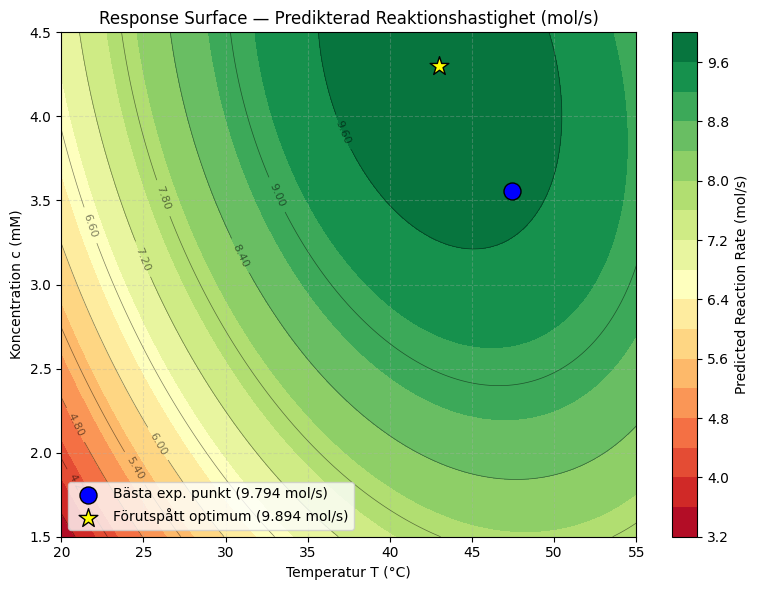

Modellens predikterade optimum på gridden:
  T = 43.02 °C
  c = 4.299 mM
  Predikterad Rate = 9.8937 mol/s

Bästa körda experimentet i historiken:
  T = 47.44 °C
  c = 3.555 mM
  Uppmätt Rate = 9.7943 mol/s


In [32]:
# TODO:
# 1. Build a grid over your explored (c, T) region. You will need
# to decide on the factor ranges, and the number of grid points.
# 2. Predict the rate with your fitted model at every grid point.
# 3. Make a contour plot using plt.contourf / ax.contour.
# Mark your best experimental point and the model's predicted optimum
# (e.g. from scipy.optimize.minimize on the negative of
# your fitted model, or just the grid's argmax).

# 1. Build a grid over the (T, c) region.
T_grid = np.linspace(20.0, 55.0, 150)
c_grid = np.linspace(1.5, 4.5, 150)

T_mesh, c_mesh = np.meshgrid(T_grid, c_grid)

# 2. Predict the rate with the fitted model at every grid point
pred_df = pd.DataFrame({
    'T': T_mesh.ravel(),
    'c': c_mesh.ravel()
})

Z = quad_model.predict(pred_df).values.reshape(T_mesh.shape)

# Find the predicted optimum on the grid
opt_idx = np.unravel_index(Z.argmax(), Z.shape)
T_opt_pred = T_mesh[opt_idx]
c_opt_pred = c_mesh[opt_idx]
rate_opt_pred = Z[opt_idx]

# Find the best actual experimental point from history
best_exp_idx = history['rate'].idxmax()
best_exp = history.loc[best_exp_idx]
T_best_exp = best_exp['T']
c_best_exp = best_exp['c']
rate_best_exp = best_exp['rate']

# 3. Make a contour plot
plt.figure(figsize=(8, 6))
cf = plt.contourf(T_mesh, c_mesh, Z, levels=20, cmap='RdYlGn')
plt.colorbar(cf, label='Predicted Reaction Rate (mol/s)')

# Contour lines
lines = plt.contour(T_mesh, c_mesh, Z, levels=10, colors='black', linewidths=0.5, alpha=0.5)
plt.clabel(lines, inline=True, fontsize=8, fmt='%.2f')

# Best experimental point
plt.scatter(T_best_exp, c_best_exp, s=150, c='blue', marker='o', edgecolors='black',
            label=f"Bästa exp. punkt ({rate_best_exp:.3f} mol/s)", zorder=5)

# Predicted optimum
plt.scatter(T_opt_pred, c_opt_pred, s=200, c='yellow', marker='*', edgecolors='black',
            label=f"Förutspått optimum ({rate_opt_pred:.3f} mol/s)", zorder=5)

plt.xlabel('Temperatur T (°C)')
plt.ylabel('Koncentration c (mM)')
plt.title('Response Surface — Predikterad Reaktionshastighet (mol/s)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Modellens predikterade optimum på gridden:")
print(f"  T = {T_opt_pred:.2f} °C")
print(f"  c = {c_opt_pred:.3f} mM")
print(f"  Predikterad Rate = {rate_opt_pred:.4f} mol/s\n")

print(f"Bästa körda experimentet i historiken:")
print(f"  T = {T_best_exp:.2f} °C")
print(f"  c = {c_best_exp:.3f} mM")
print(f"  Uppmätt Rate = {rate_best_exp:.4f} mol/s")

In [33]:
# TODO:
# 1. Store the predicted optimum (c_star, T_star, rate_star)
# -- you'll reuse it in Step 4.
# 2. Run 1-2 confirmation experiments at (or near) your predicted optimum
# and compare the observed rate to the model's prediction.
c_star, T_star, rate_star = c_opt_pred, T_opt_pred, rate_opt_pred

result = run_experiment(
        name=f'Predicted_Optimum:_1',
        T=[T_star],
        c=[c_star],
        rpm=[fixed_rpm_value]
    )

log(result)
result = run_experiment(
        name=f'Predicted_Optimum:_2',
        T=[T_star],
        c=[c_star],
        rpm=[fixed_rpm_value]
    )

log(result)
print(f"Predicted Optimum: T={T_star:.2f} °C, c={c_star:.3f} mM -> Rate={result['rate'].iloc[0]:.4f} mol/s")

display(history.tail(12))

Team 'Labgrp17': 1 experiment(s) this call, 188 total so far.
Team 'Labgrp17': 1 experiment(s) this call, 189 total so far.
Predicted Optimum: T=43.02 °C, c=4.299 mM -> Rate=9.8093 mol/s


,T,c,rpm,rate
22,46.113022,3.461381,500.0,9.4995
23,49.570701,3.359109,500.0,9.5847
24,45.452911,3.507308,500.0,9.7717
25,49.119430,3.324939,500.0,9.5497
26,47.435943,3.555179,500.0,9.7943
27,45.814601,3.414682,500.0,9.6544
28,48.178067,3.292401,500.0,9.5872
29,48.778293,3.499410,500.0,9.6681
30,46.722708,3.410381,500.0,9.6987
31,47.586184,3.267013,500.0,9.4895


---
## Step 4 — How Sure Are You? A Confidence Interval (3:00–3:45)

- [ ] Run 8-10 replicate experiments at your predicted optimum (same T*, c*, and rpm every time).
- [ ] Compute the sample mean and standard deviation of the resulting rates
- [ ] Build a 95% confidence interval on the true mean rate there (→ **Checkpoint 4a**)
- [ ] Check whether the OVAT baseline (5.77 mol/s) and your model's predicted rate (Checkpoint 3b) fall inside or outside your CI
- [ ] Reflect on the sample-size / CI-width trade-off (→ **Checkpoint 4b**)

In [34]:
# TODO: run 8-10 replicate experiments at (c_star, T_star), same settings
# every call. log() the results.
for i in range(8):
    experiment_name = f"Predicted_Optimum_replicate:_{i+1}"

    # Run the experiment with fixed RPM
    result = run_experiment(
        name=experiment_name,
        T=[T_star],
        c=[c_star],
        rpm=[fixed_rpm_value]
    )

    log(result)
    print(f"Predicted_Optimum_replicate:{i+1}: T={T_star:.2f} °C, c={c_star:.3f} mM -> Rate={result['rate'].iloc[0]:.4f} mol/s")

display(history.tail(12))

Team 'Labgrp17': 1 experiment(s) this call, 190 total so far.
Predicted_Optimum_replicate:1: T=43.02 °C, c=4.299 mM -> Rate=9.7149 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 191 total so far.
Predicted_Optimum_replicate:2: T=43.02 °C, c=4.299 mM -> Rate=9.5576 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 192 total so far.
Predicted_Optimum_replicate:3: T=43.02 °C, c=4.299 mM -> Rate=9.5357 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 193 total so far.
Predicted_Optimum_replicate:4: T=43.02 °C, c=4.299 mM -> Rate=9.4594 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 194 total so far.
Predicted_Optimum_replicate:5: T=43.02 °C, c=4.299 mM -> Rate=9.4415 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 195 total so far.
Predicted_Optimum_replicate:6: T=43.02 °C, c=4.299 mM -> Rate=9.0777 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 196 total so far.
Predicted_Optimum_replicate:7: T=43.02 °C, c=4.299 mM -> Rate=9.4727 mol/s
Team 'Labgrp17': 1 experiment(s) this cal

,T,c,rpm,rate
30,46.722708,3.410381,500.0,9.6987
31,47.586184,3.267013,500.0,9.4895
32,43.020134,4.298658,500.0,9.5288
33,43.020134,4.298658,500.0,9.8093
34,43.020134,4.298658,500.0,9.7149
35,43.020134,4.298658,500.0,9.5576
36,43.020134,4.298658,500.0,9.5357
37,43.020134,4.298658,500.0,9.4594
38,43.020134,4.298658,500.0,9.4415
39,43.020134,4.298658,500.0,9.0777


In [35]:
# TODO: compute mean, standard deviation (ddof=1), and a 95% confidence
# interval on the mean rate. Use scipy.stats.t.ppf(0.975, df=n-1) for the
# critical value -- same one-sample CI construction as Part III.
# Then check: does 5.77 (OVAT) fall inside your CI? Does your Step 3
# predicted rate (rate_star) fall inside your CI?

replicate_runs = history.tail(8)
#statistics on the replicates
mean = replicate_runs['rate'].mean()
std_dev = replicate_runs['rate'].std(ddof=1)
n = len(replicate_runs)

#Calculate 95% confidence interval using critical t-value
t_critical = stats.t.ppf(0.975, df=n-1)
margin_of_error = t_critical * (std_dev / np.sqrt(n))

ci_lower = mean - margin_of_error
ci_upper = mean + margin_of_error

print(f"--- Resultat för {n} replikat vid predikterat optimum ---")
print(f"Medelvärde (Mean): {mean:.4f} mol/s")
print(f"Standardavvikelse (Std Dev): {std_dev:.4f} mol/s")
print(f"95% Konfidensintervall på medelvärdet: [{ci_lower:.4f}, {ci_upper:.4f}] mol/s\n")

ovat_baseline = 5.77
print(f"Ligger OVAT-baslinjen ({ovat_baseline} mol/s) inom konfidensintervallet? ")
if ci_lower <= ovat_baseline <= ci_upper:
    print("  -> JA")
else:
    print("  -> NEJ")

print(f"\nLigger modellens predikterade hastighet (rate_star = {rate_star:.4f} mol/s) inom intervallet? ")
if ci_lower <= rate_star <= ci_upper:
    print("  -> JA")
else:
    print("  -> NEJ")

--- Resultat för 8 replikat vid predikterat optimum ---
Medelvärde (Mean): 9.4798 mol/s
Standardavvikelse (Std Dev): 0.1844 mol/s
95% Konfidensintervall på medelvärdet: [9.3257, 9.6340] mol/s

Ligger OVAT-baslinjen (5.77 mol/s) inom konfidensintervallet? 
  -> NEJ

Ligger modellens predikterade hastighet (rate_star = 9.8937 mol/s) inom intervallet? 
  -> NEJ


In [36]:
# TODO (Checkpoint 4b): using your own n and CI half-width, work out
# roughly how many replicates you'd need to halve the half-width
# (half-width shrinks with 1/sqrt(n)). Is that trade worth it given the
# contest rewards fewer experiments? Write your reasoning on the answer
# sheet, not just the number here.


---
## Wrap-up (3:45–4:00)

- [ ] Check your final experiment count and best rate with `leaderboard()`
- [ ] Compute your % improvement over the OVAT baseline of 5.77 mol/s
- [ ] Finalise your answer sheet (Checkpoints 1a–4c)

In [37]:
# TODO: leaderboard() and a final summary print of best rate found,
# total experiments used, and % improvement over 5.77 mol/s.
display(history)

,T,c,rpm,rate
0,20.000000,1.500000,300.0,3.2950
1,20.000000,1.500000,700.0,3.3052
2,20.000000,2.500000,300.0,5.0280
3,20.000000,2.500000,700.0,5.0740
4,30.000000,1.500000,300.0,6.0717
5,30.000000,1.500000,700.0,5.9831
6,30.000000,2.500000,300.0,7.6099
7,30.000000,2.500000,700.0,7.5287
8,25.000000,2.000000,500.0,5.5246
9,25.000000,2.000000,500.0,5.7880
